Установка и импорт библиотек:

In [ ]:
!pip install -q kagglehub tensorflow
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.regularizers import l1, l2
import warnings
warnings.filterwarnings('ignore')

print("GPU доступен:", tf.config.list_physical_devices('GPU'))

GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Загрузка датасета с Kaggle

In [ ]:
file_path = "manufacturing_6G_dataset.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ziya07/intelligent-manufacturing-dataset",
    file_path
)
print("Данные загружены, размер:", df.shape)
df.head()

Using Colab cache for faster access to the 'intelligent-manufacturing-dataset' dataset.
Данные загружены, размер: (100000, 13)


,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,2024-01-01 00:00:00,39,Idle,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470,Low
1,2024-01-01 00:01:00,29,Active,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270,Low
2,2024-01-01 00:02:00,15,Active,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391,Low
3,2024-01-01 00:03:00,43,Active,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847,Medium
4,2024-01-01 00:04:00,8,Idle,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686,Low


Предобработка данных

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

# Выбор признаков и целевой переменной
features = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%',
    'Quality_Control_Defect_Rate_%', 'Production_Speed_units_per_hr',
    'Error_Rate_%'
]
target = 'Predictive_Maintenance_Score'

data = df[features + [target]].dropna()

# Нормализация
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
data[features] = scaler_x.fit_transform(data[features])
data[[target]] = scaler_y.fit_transform(data[[target]])

# Формирование последовательностей для RNN
def create_sequences(X, y, lookback=10):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

LOOKBACK = 10
X = data[features].values
y = data[target].values
X_seq, y_seq = create_sequences(X, y, LOOKBACK)

# Разделение на train/test
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (79992, 10, 8), Test shape: (19998, 10, 8)


Функция построения модели

In [ ]:
def build_model(rnn_type='LSTM', optimizer='adam', regularizer=None, units=50):
    model = Sequential()
    if rnn_type == 'SimpleRNN':
        layer = SimpleRNN(units, activation='tanh', return_sequences=False,
                          kernel_regularizer=regularizer)
    elif rnn_type == 'LSTM':
        layer = LSTM(units, activation='tanh', return_sequences=False,
                     kernel_regularizer=regularizer)
    elif rnn_type == 'GRU':
        layer = GRU(units, activation='tanh', return_sequences=False,
                    kernel_regularizer=regularizer)
    else:
        raise ValueError("Unknown rnn_type")
    model.add(layer)
    model.add(Dense(1))

    if optimizer == 'sgd':
        opt = SGD(learning_rate=0.01, momentum=0.0)
    elif optimizer == 'momentum':
        opt = SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=0.001)
    elif optimizer == 'adam':
        opt = Adam(learning_rate=0.001)
    else:
        raise ValueError("Unknown optimizer")

    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

Эксперименты (3 архитектуры × 4 оптимизатора + 3 архитектуры × 2 регуляризации)

In [ ]:
architectures = ['SimpleRNN', 'LSTM', 'GRU']
optimizers = ['sgd', 'momentum', 'rmsprop', 'adam']
regularizers = {'L1': l1(0.001), 'L2': l2(0.001)}

results = []
history_dict = {}

# Сравнение оптимизаторов
for arch in architectures:
    for opt in optimizers:
        name = f"{arch}_{opt}"
        print(f"\nОбучение: {name}")
        model = build_model(rnn_type=arch, optimizer=opt, regularizer=None)
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=20, batch_size=64,
            verbose=0
        )
        history_dict[name] = history
        y_pred = model.predict(X_test, verbose=0)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        results.append({
            'name': name,
            'arch': arch,
            'optimizer': opt,
            'regularizer': 'None',
            'mse': mse,
            'mae': mae,
            'history': history
        })

# Сравнение регуляризации (фиксированный Adam)
for arch in architectures:
    for reg_name, reg in regularizers.items():
        name = f"{arch}_adam_{reg_name}"
        print(f"\nОбучение: {name}")
        model = build_model(rnn_type=arch, optimizer='adam', regularizer=reg)
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=20, batch_size=64,
            verbose=0
        )
        history_dict[name] = history
        y_pred = model.predict(X_test, verbose=0)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        results.append({
            'name': name,
            'arch': arch,
            'optimizer': 'adam',
            'regularizer': reg_name,
            'mse': mse,
            'mae': mae,
            'history': history
        })


Обучение: SimpleRNN_sgd

Обучение: SimpleRNN_momentum

Обучение: SimpleRNN_rmsprop

Обучение: SimpleRNN_adam

Обучение: LSTM_sgd

Обучение: LSTM_momentum

Обучение: LSTM_rmsprop

Обучение: LSTM_adam

Обучение: GRU_sgd

Обучение: GRU_momentum

Обучение: GRU_rmsprop

Обучение: GRU_adam

Обучение: SimpleRNN_adam_L1

Обучение: SimpleRNN_adam_L2

Обучение: LSTM_adam_L1

Обучение: LSTM_adam_L2

Обучение: GRU_adam_L1

Обучение: GRU_adam_L2


Визуализация результатов

Кривые обучения (loss)

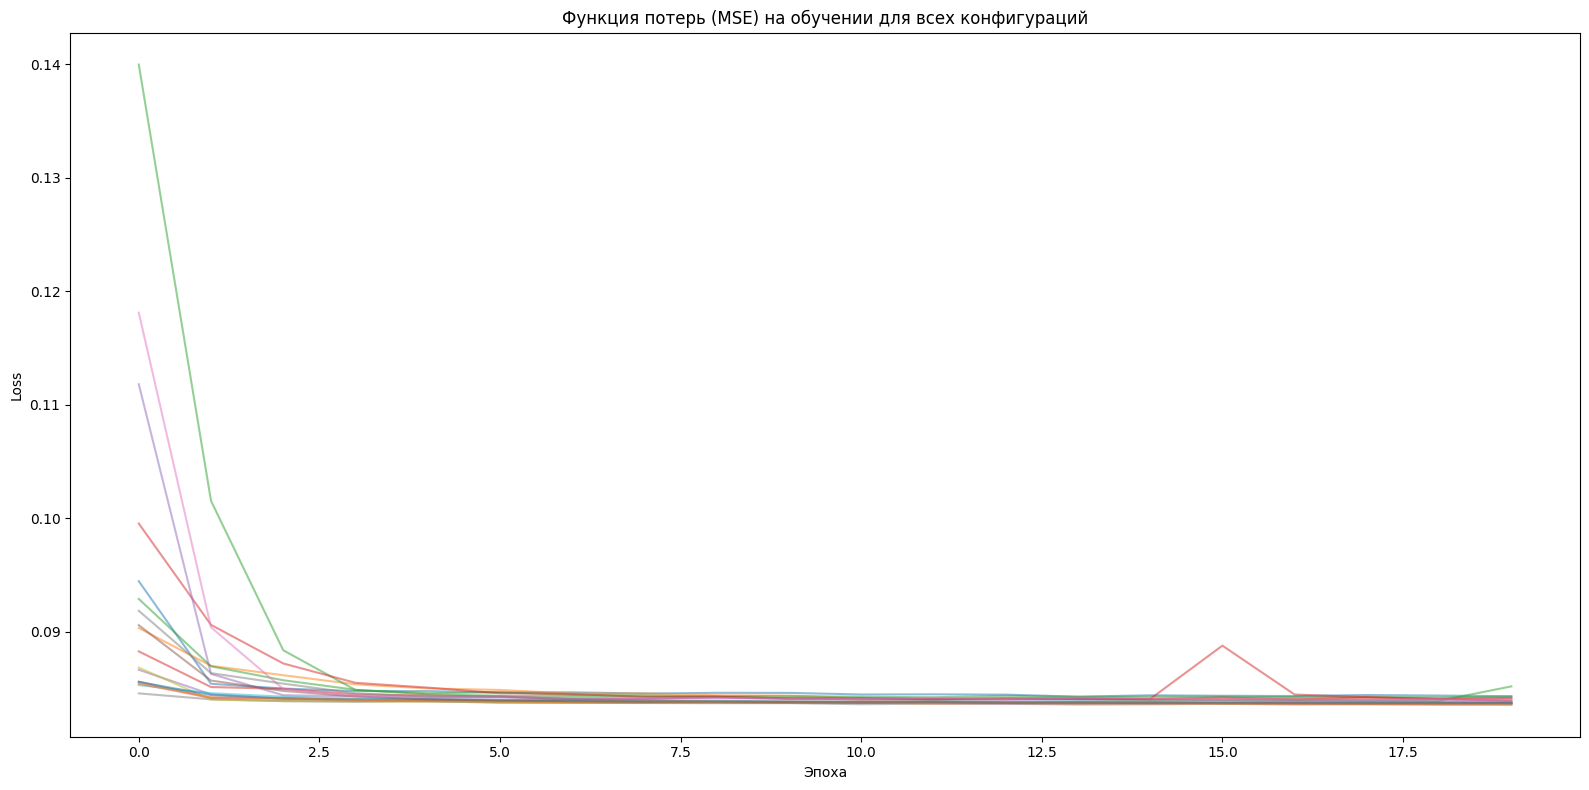

In [ ]:
plt.figure(figsize=(16, 8))
for res in results:
    plt.plot(res['history'].history['loss'], alpha=0.5, label=res['name'])
plt.title('Функция потерь (MSE) на обучении для всех конфигураций')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

Таблица результатов

In [ ]:
df_res = pd.DataFrame(results)[['name', 'arch', 'optimizer', 'regularizer', 'mse', 'mae']]
print("\nРезультаты всех экспериментов (MSE, MAE):")
print(df_res.sort_values('mse'))


Результаты всех экспериментов (MSE, MAE):
                  name       arch optimizer regularizer       mse       mae
15        LSTM_adam_L2       LSTM      adam          L2  0.083501  0.250255
16         GRU_adam_L1        GRU      adam          L1  0.083514  0.250269
4             LSTM_sgd       LSTM       sgd        None  0.083524  0.250285
17         GRU_adam_L2        GRU      adam          L2  0.083546  0.250297
9         GRU_momentum        GRU  momentum        None  0.083546  0.250284
13   SimpleRNN_adam_L2  SimpleRNN      adam          L2  0.083556  0.250300
6         LSTM_rmsprop       LSTM   rmsprop        None  0.083560  0.250279
8              GRU_sgd        GRU       sgd        None  0.083591  0.250299
7            LSTM_adam       LSTM      adam        None  0.083607  0.250343
11            GRU_adam        GRU      adam        None  0.083686  0.250440
10         GRU_rmsprop        GRU   rmsprop        None  0.083690  0.250410
5        LSTM_momentum       LSTM  momentum  

Сравнение MSE по архитектурам и оптимизаторам

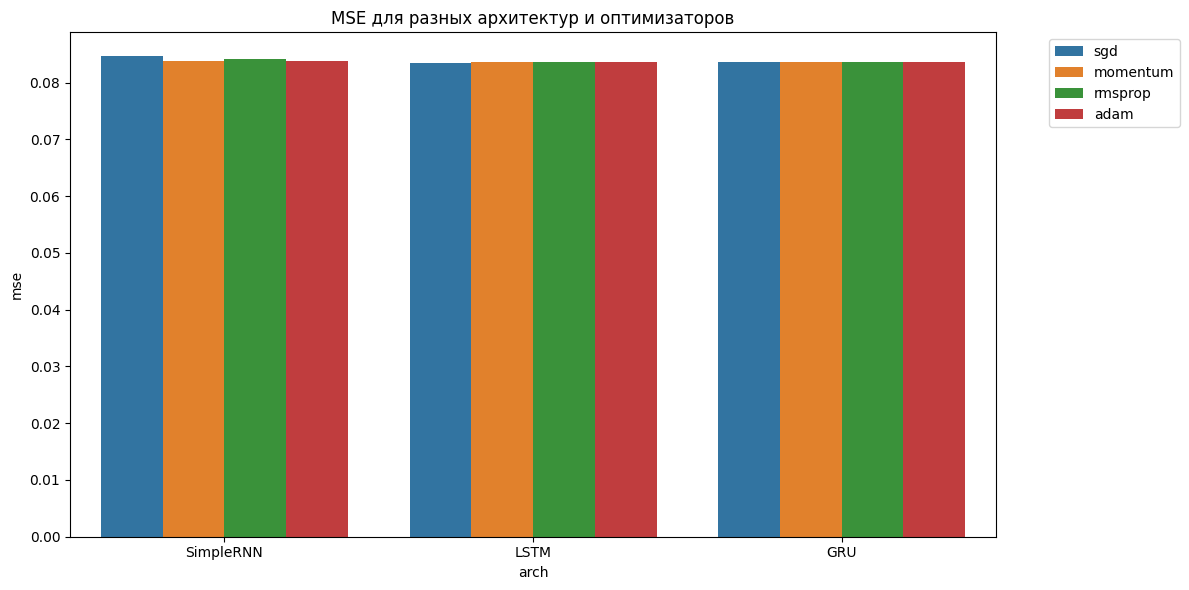

In [ ]:
df_opt = df_res[df_res['regularizer'] == 'None']
plt.figure(figsize=(12, 6))
sns.barplot(data=df_opt, x='arch', y='mse', hue='optimizer')
plt.title('MSE для разных архитектур и оптимизаторов')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Влияние регуляризации

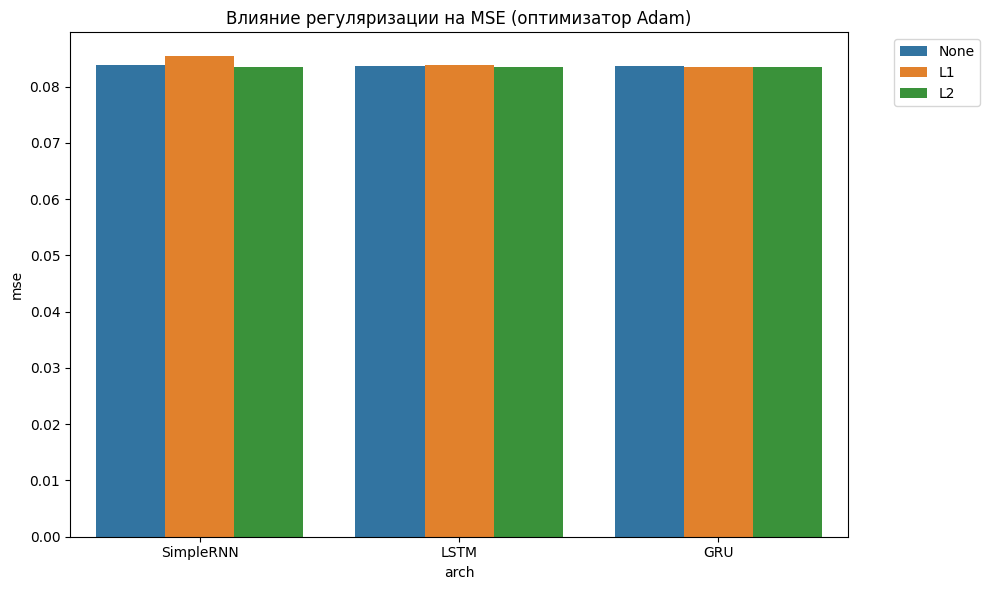

In [ ]:
df_reg = df_res[df_res['optimizer'] == 'adam']
plt.figure(figsize=(10, 6))
sns.barplot(data=df_reg, x='arch', y='mse', hue='regularizer')
plt.title('Влияние регуляризации на MSE (оптимизатор Adam)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Тепловая карта корреляции признаков

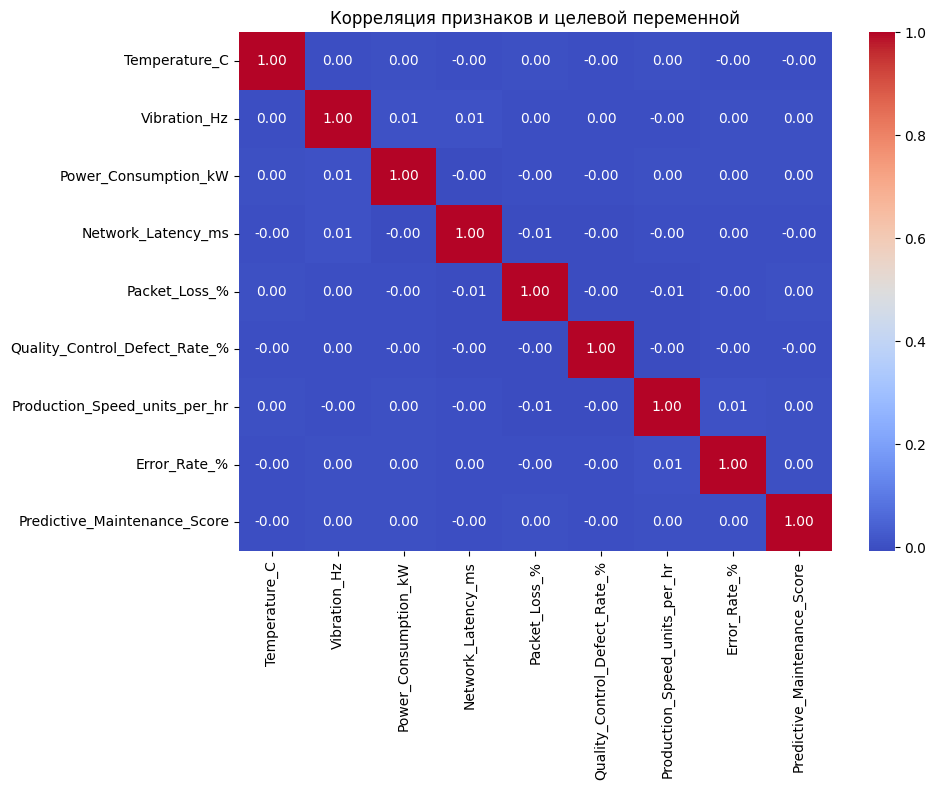

In [ ]:

plt.figure(figsize=(10, 8))
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков и целевой переменной')
plt.tight_layout()
plt.show()

Прогноз лучшей модели


Лучшая модель: LSTM_adam_L2 с MSE=0.083501


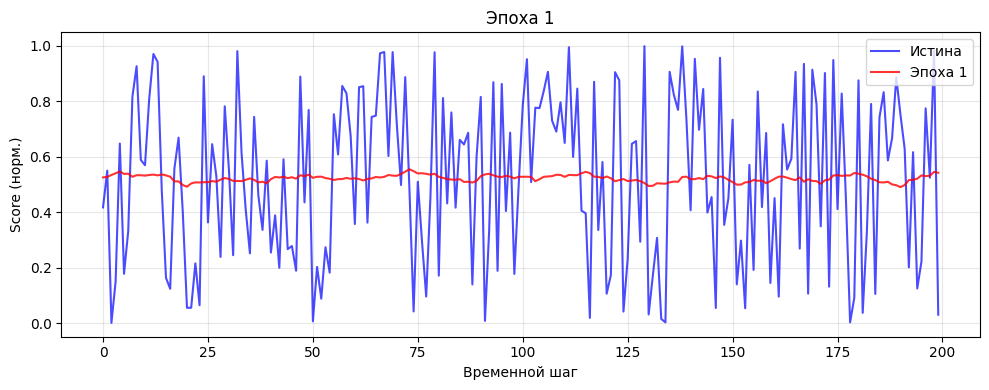

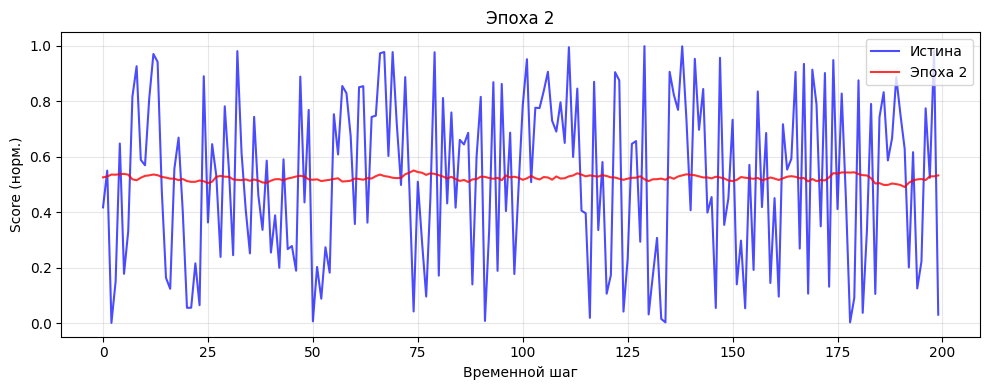

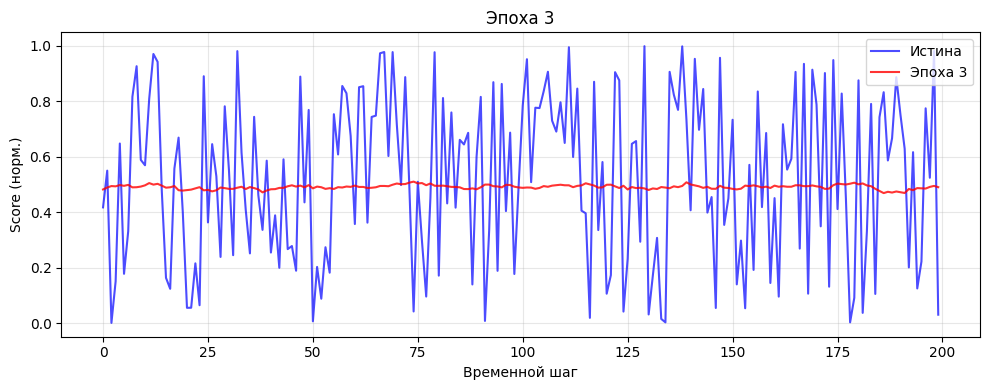

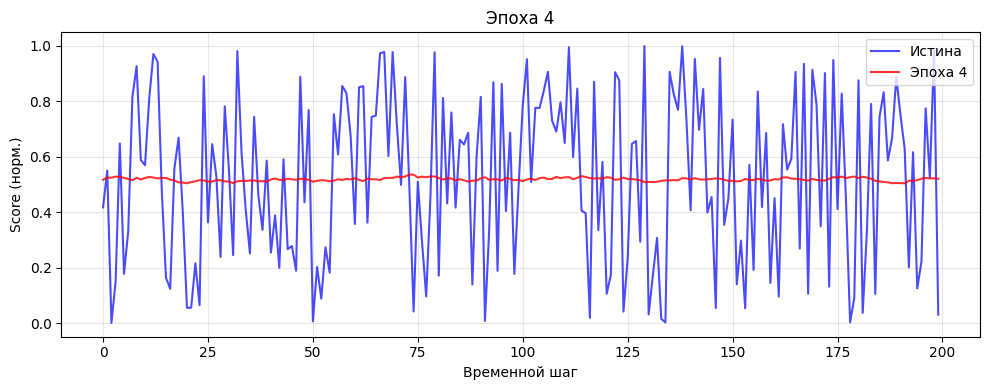

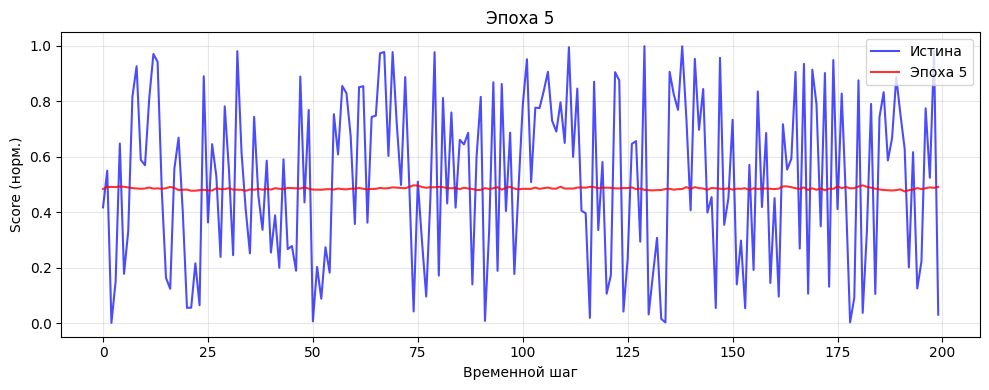

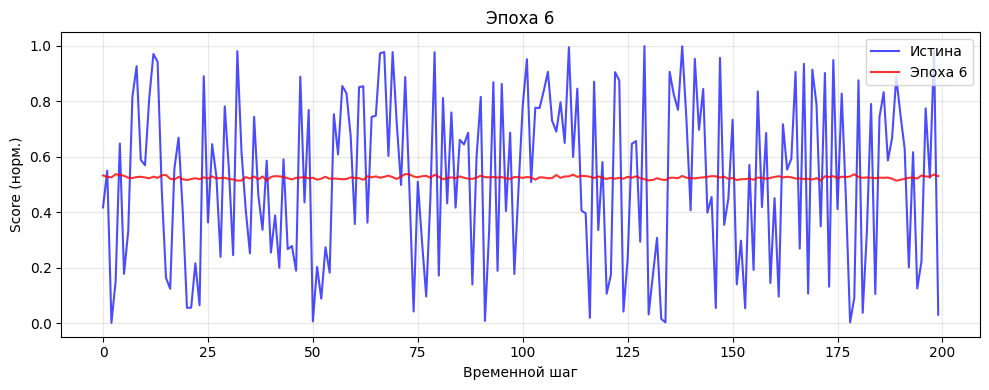

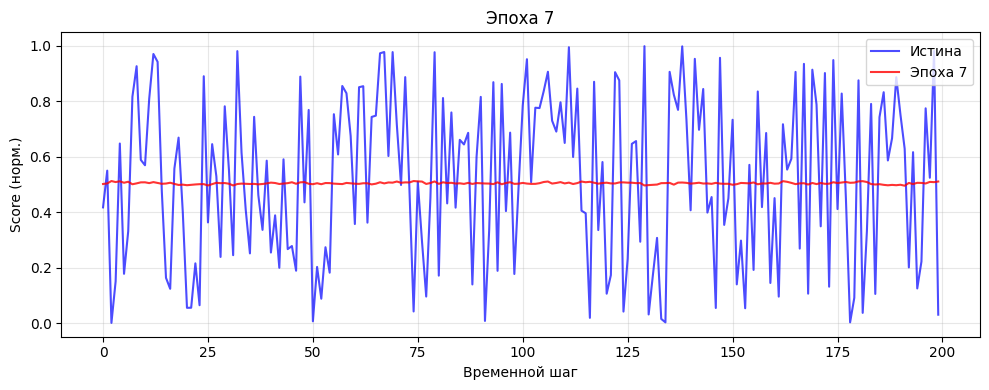

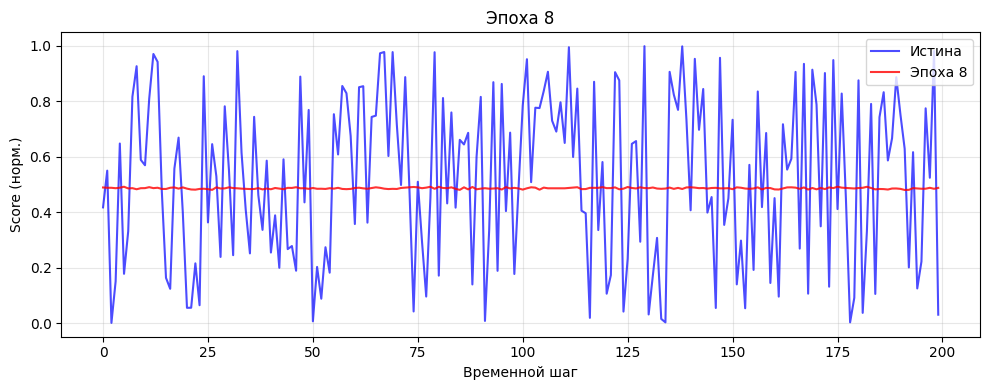

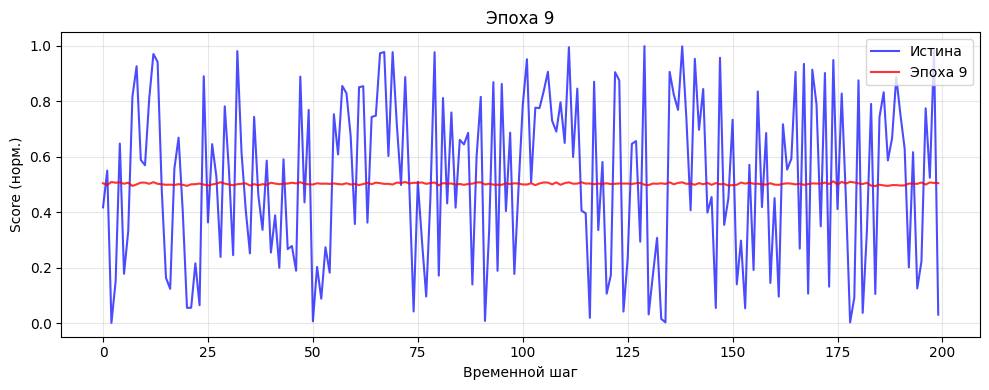

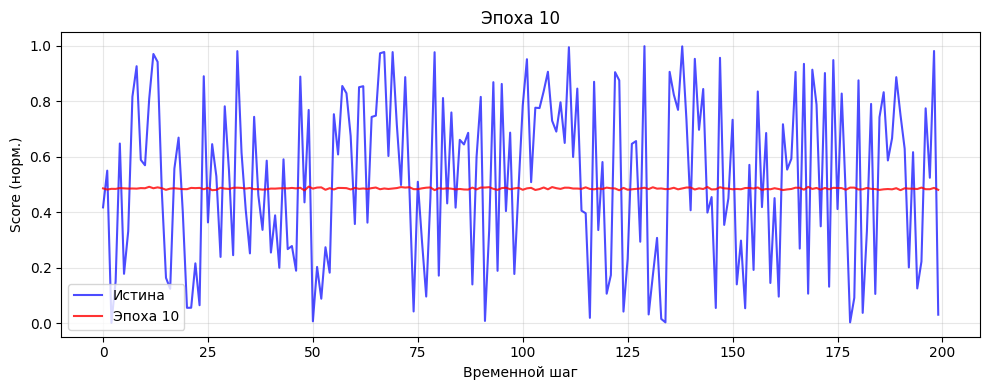

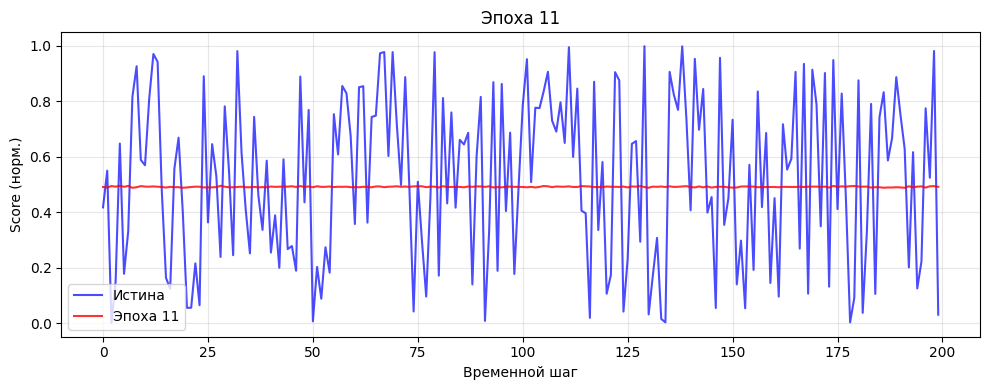

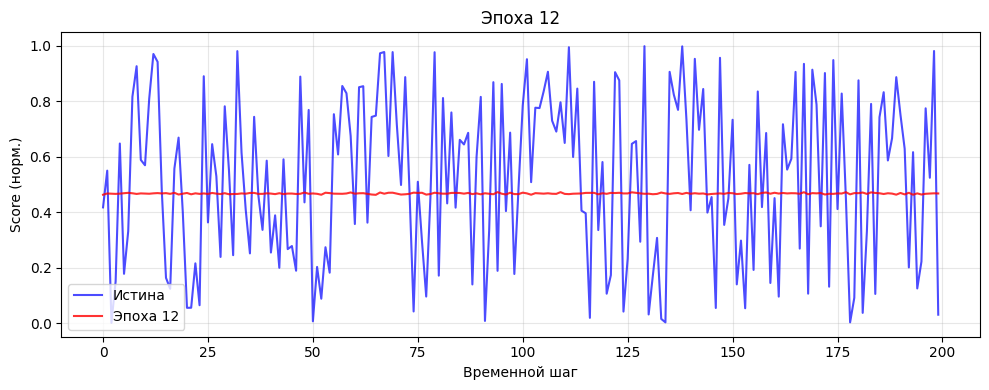

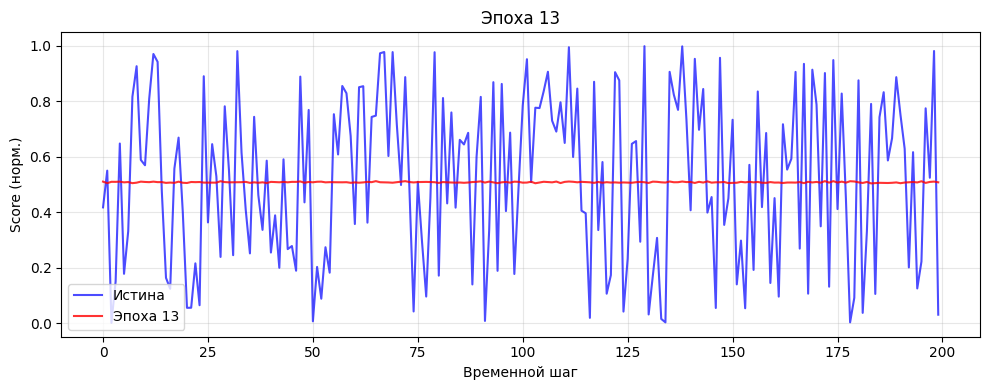

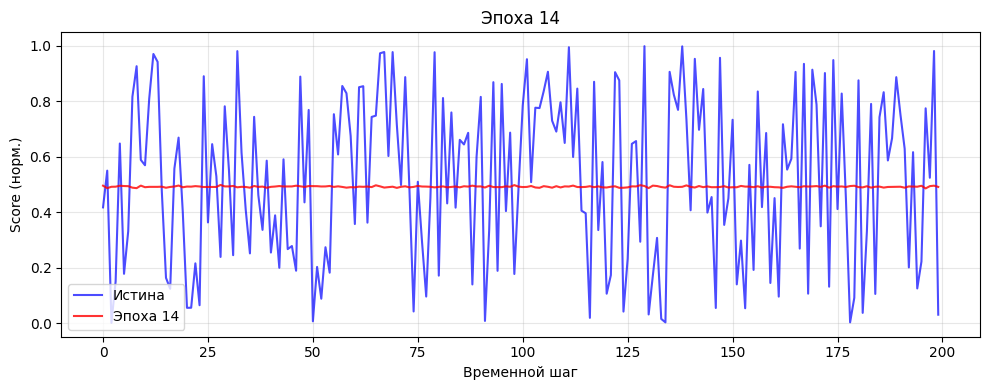

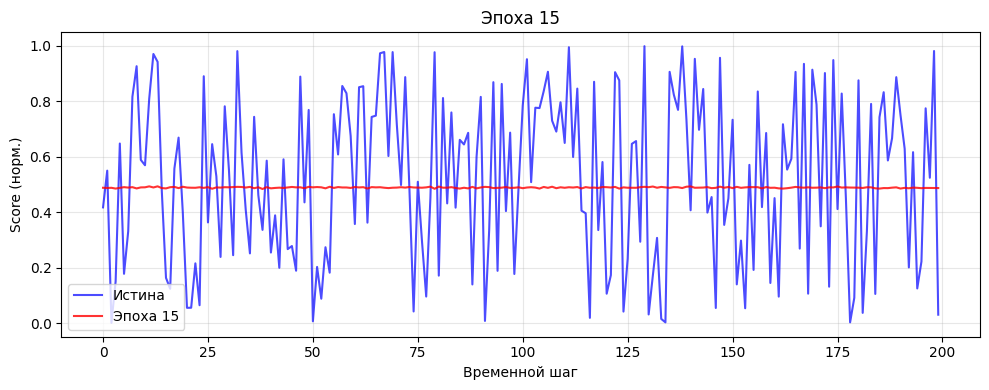

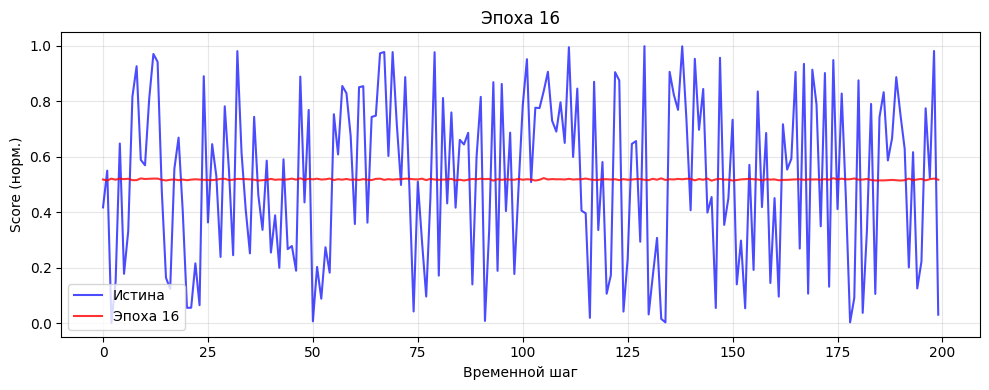

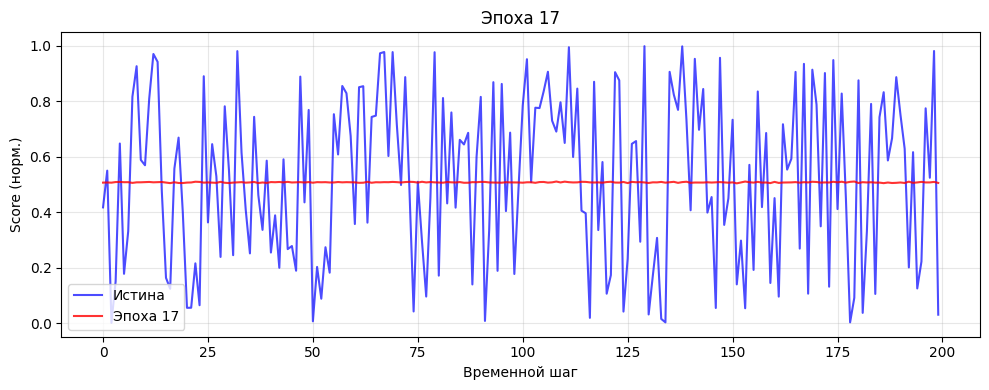

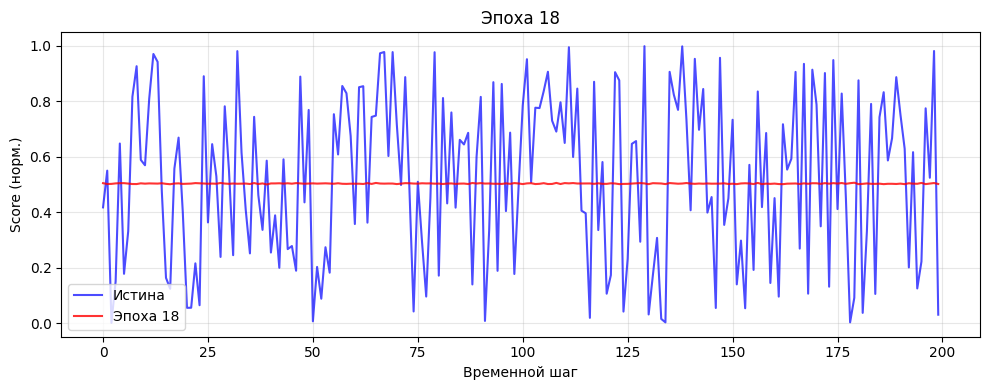

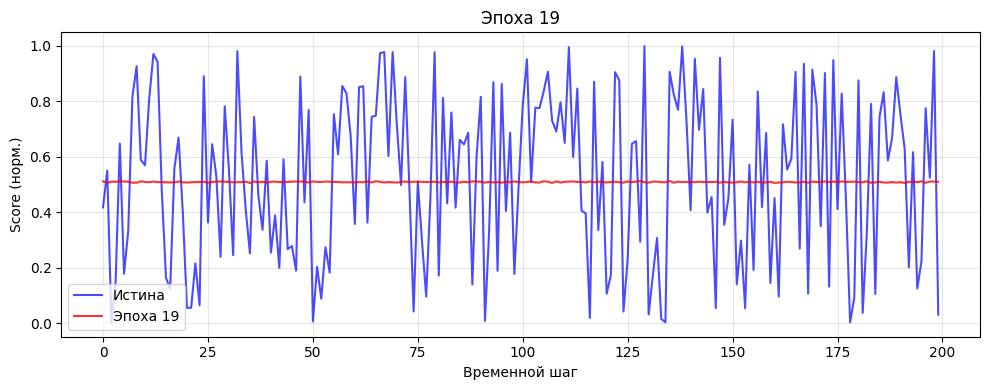

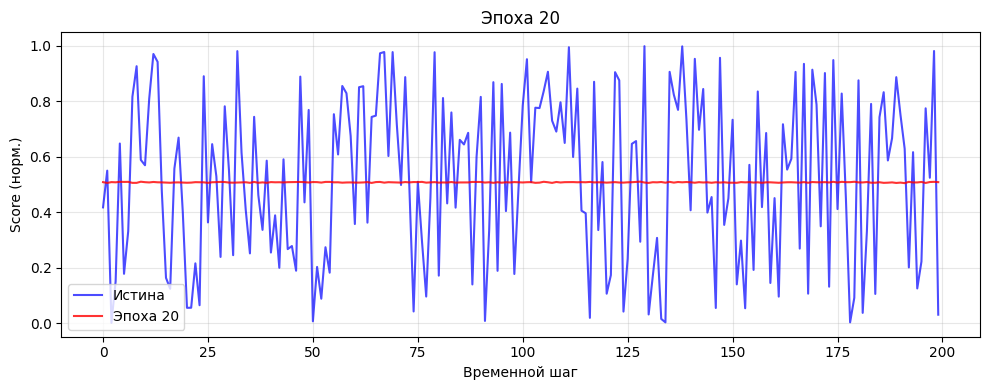

In [ ]:
best_row = df_res.loc[df_res['mse'].idxmin()]
print(f"\nЛучшая модель: {best_row['name']} с MSE={best_row['mse']:.6f}")

best_model = build_model(
    rnn_type=best_row['arch'],
    optimizer=best_row['optimizer'],
    regularizer=l1(0.001) if best_row['regularizer']=='L1' else (l2(0.001) if best_row['regularizer']=='L2' else None)
)

class EpochPredictions(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(X_test, verbose=0)
        self.model.epoch_predictions.append(y_pred.copy())

epochs = 20
best_model.epoch_predictions = []
best_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=64,
    verbose=0,
    callbacks=[EpochPredictions()]
)

preds = best_model.epoch_predictions
y_test_flat = y_test.flatten()
n_points = 200
x_axis = np.arange(n_points)

epochs_to_show = list(range(0, epochs))
epochs_to_show = sorted(set(epochs_to_show))

for epoch in epochs_to_show:
    plt.figure(figsize=(10, 4))
    plt.plot(x_axis, y_test_flat[:n_points], 'b-', label='Истина', alpha=0.7)
    plt.plot(x_axis, preds[epoch][:n_points].flatten(), 'r-', label=f'Эпоха {epoch+1}', alpha=0.8)
    plt.title(f'Эпоха {epoch+1}')
    plt.xlabel('Временной шаг')
    plt.ylabel('Score (норм.)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()